# Demo 1: Noise Generator

We gonna show how to simultate our cantilever's thermal noise in this demo

In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd().parent   # demo/data → demo → browniansim/
sys.path.insert(0, str(repo_root))
import browniansim as fc

import numpy as np
import matplotlib.pyplot as plt

# Simulate ring down trajectory

There are two approaches to fit the trajectory of the ring down motion: using the analytical solution directly and using our simulator to perform the fitting. We will try both methods.

In this simulator, time is normalized and denoted as $\tau$, where $\tau = w_0 t$. That is to say, $\tau$ is a dimensionless parameter defined by multiplying the physical time $t$ with the resonant angular frequency $w_0$ of the system. Therefore, the equation to be solved is:

$\frac{d^2x}{d\tau^2}+\frac{1}{Q}\frac{dx}{d\tau}+x = \frac{F}{mw_0^2}$

We can then define the simulation step size dtau, which actually represents how many oscillator periods are covered by one simulation time step (for example, if dtau=0.1*2pi, it covers 0.1 oscillator period per step). After the simulation is completed, the user just needs to divide the time series by the cantilever angular frequency $w_0$ to obtain the correct time series. As for the simulated displacement series, it contains two columns: the first column is $x$, representing the displacement sequence in meters; the second column is $\frac{dx}{d\tau}$, the normalized velocity sequence, also in meters. By dividing by $w_0$, the correct velocity sequence can also be restored.

Here is our simulator:

```python
def solve_RK4(X0, dtau, Q, F,dw):
    """
    Solve the damped harmonic oscillator equation using the Runge-Kutta 4th order method. This function is designed for the case where the frequency has a rapid change, so in our RK4 method, we need to simulate the frequency at t+dt/2.
    Parameters:
        X0[array[2]]: initial displacement, velocity devided by w0.
        dtau[float]: time step*w0.
        Q[float]: quality factor.
        F[array[n,4]]: force devided by the mass and w0 squared.
        dw[array[n,4]]: effective frequency shift, dw = (w-w0)/w0.
    Return:
        X[array]: displacement, velocity devided by w0.
    """
    if len(X0) != 2:
        raise ValueError("X0 must have 2 elements")
    if F.ndim != 2 or F.shape[1] != 4:
        raise ValueError("F must be a 2D array with 4 columns")
    if dw.ndim != 2 or dw.shape[1] != 4:
        raise ValueError("dw must be a 2D array with 4 columns")
    if np.shape(dw)[0] != np.shape(F)[0]:
        raise ValueError("dw and F must have the same length")
    X = np.zeros([np.shape(F)[0], 2])  # F is the force time-series. For the Euler method, each result corresponds to one F. For RK4, we need to use four F values for each step!
    X[0] = X0
    for n in range(np.shape(F)[0]-1):
        k1 = harmosc_shiftw(X[n], Q, F[n][0],dw[n][0])
        k2 = harmosc_shiftw(X[n] + dtau * k1 / 2, Q, F[n][1],dw[n][1])
        k3 = harmosc_shiftw(X[n] + dtau * k2 / 2, Q, F[n][2],dw[n][2])
        k4 = harmosc_shiftw(X[n] + dtau * k3, Q, F[n][3],dw[n][3])
        X[n+1, :] =  X[n, :] + dtau * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return X

def harmosc_shiftw(X, Q, F,dw):
    """
    Damped harmonic oscillator with random driving force. Note: this differential equation treats time as time*w0, displacement as x, and momentum as velocity/w0.
    Parameters:
        X[array]: displacement, velocity.
        Q[float]: quality factor.
        F[array]: force devided by mass and w0 squared.
        dw[array]: frequency shift, dw = (w-w0)/w0.
        x[float]: displacement.
        p[float]: velocity/w0.
        dotx[float]: change of displacement.
        dotp[float]: change of velocity.
    Return:
        dotx, dotp[array]: change of displacement and velocity/w0.
    """
    x, p = X
    dotx = p
    dotp = - (1+dw)**2 * x - (1 / Q) * p + F
    return np.array([dotx, dotp])
```

----------------------------------------------------------------------------------------------
Q= 1


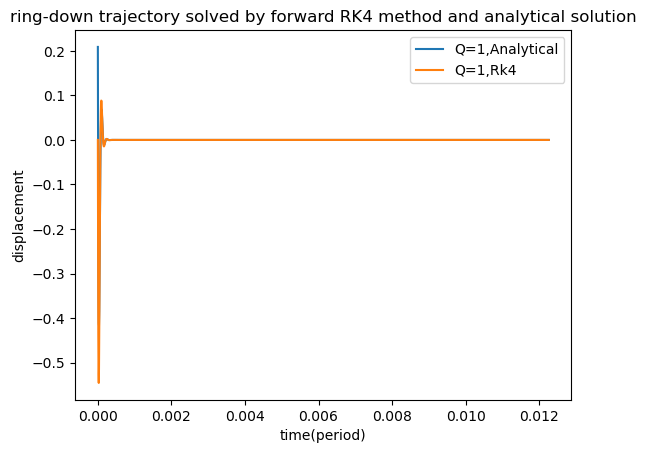

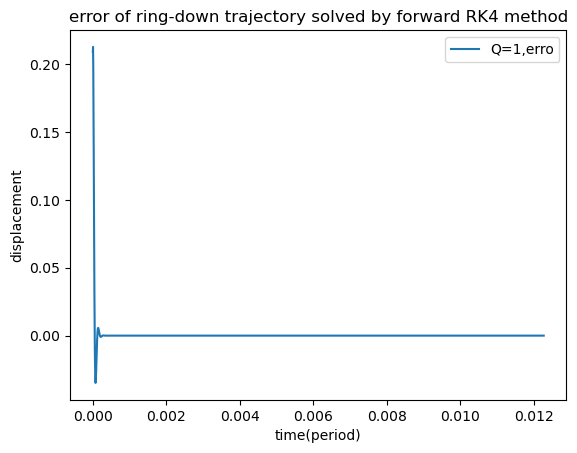

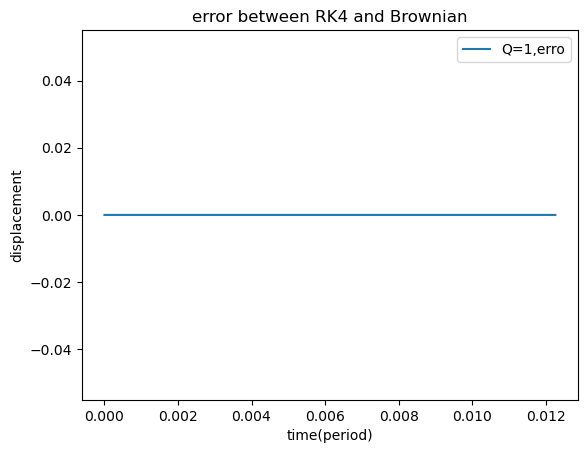

----------------------------------------------------------------------------------------------
Q= 10


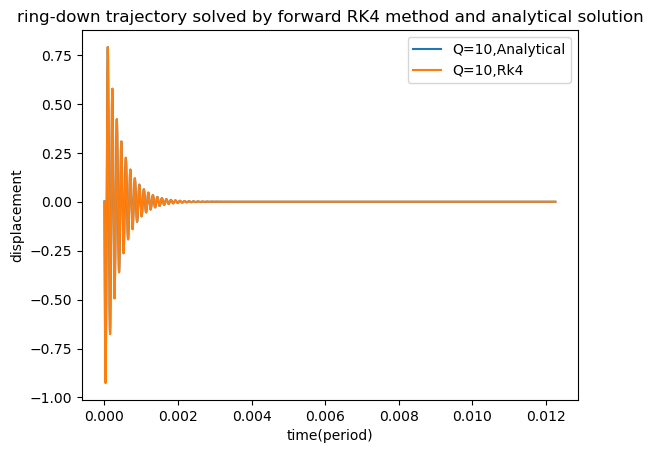

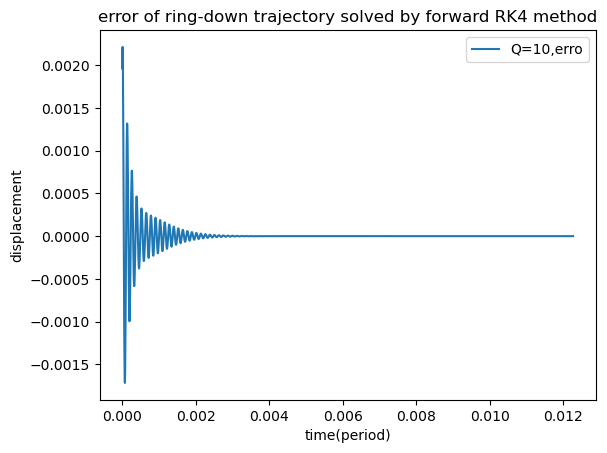

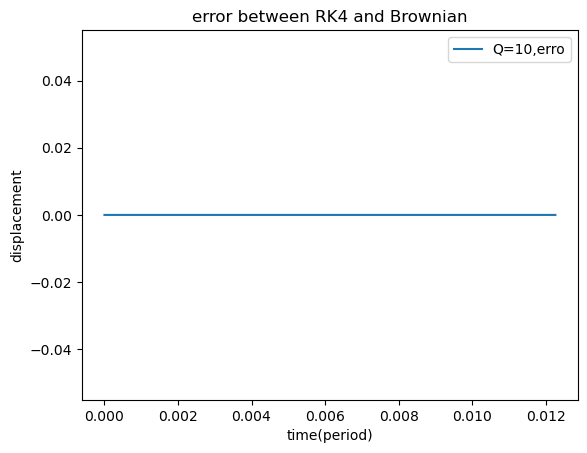

----------------------------------------------------------------------------------------------
Q= 100


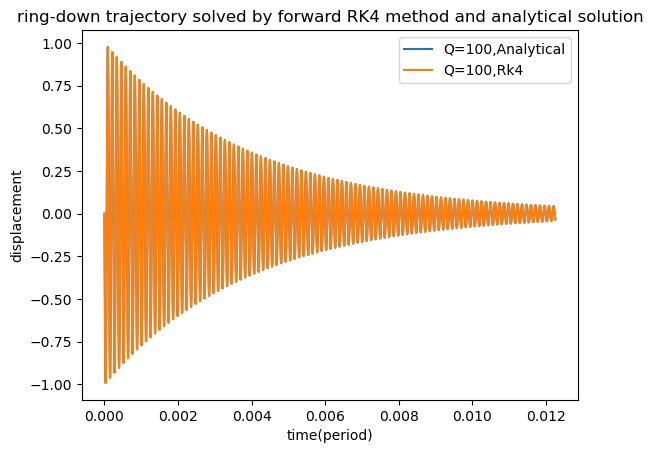

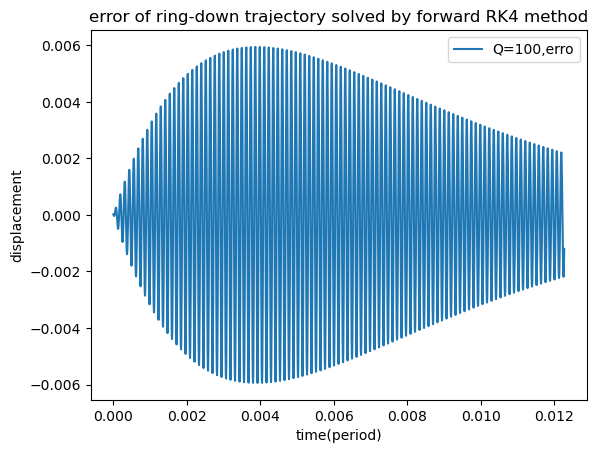

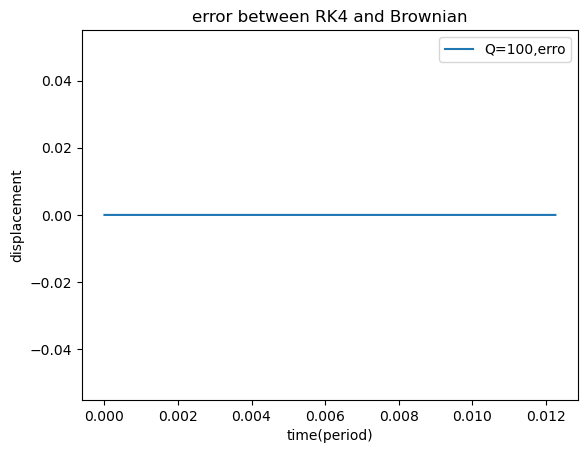

----------------------------------------------------------------------------------------------
Q= 1000


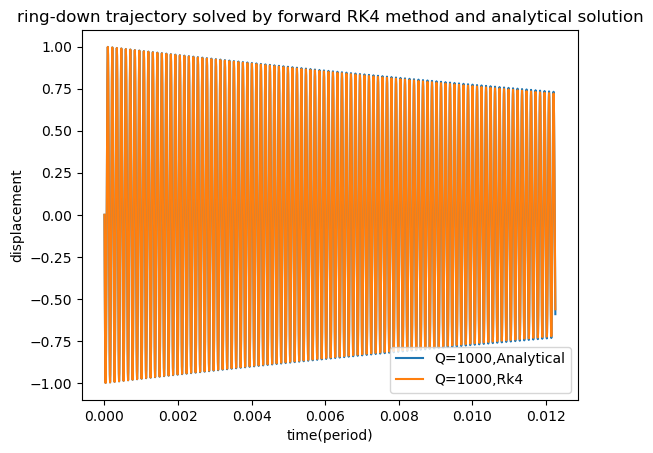

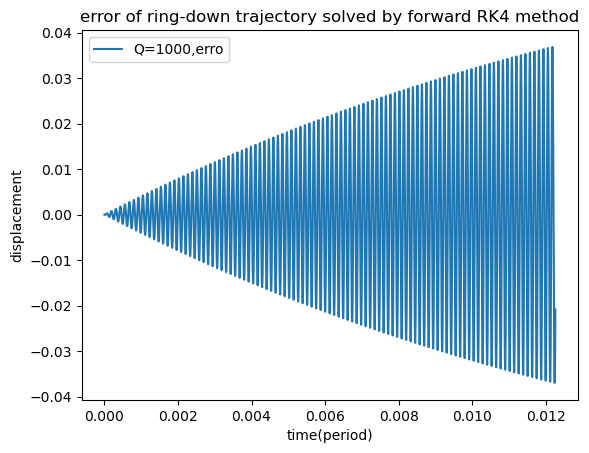

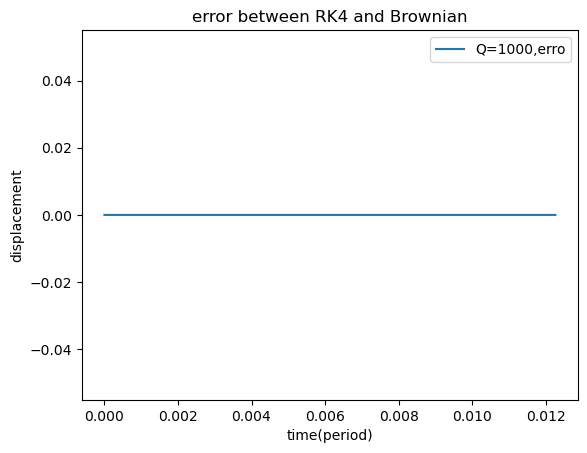

----------------------------------------------------------------------------------------------
Q= 15000


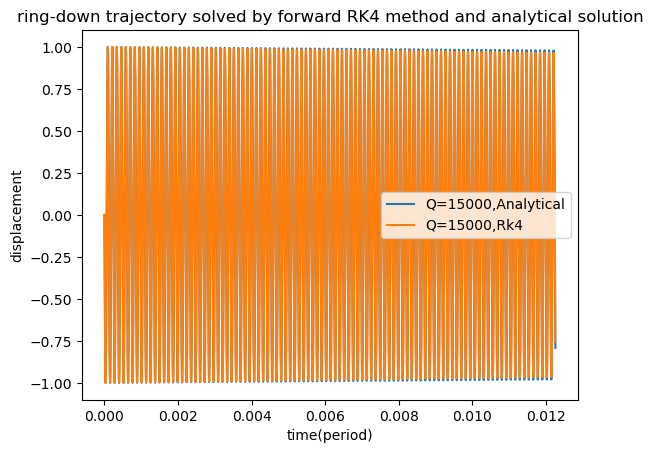

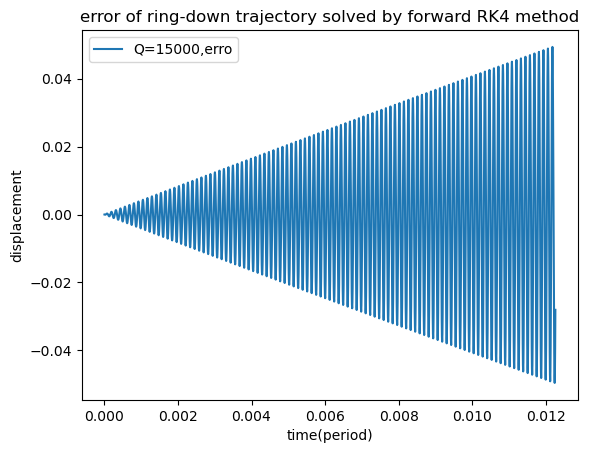

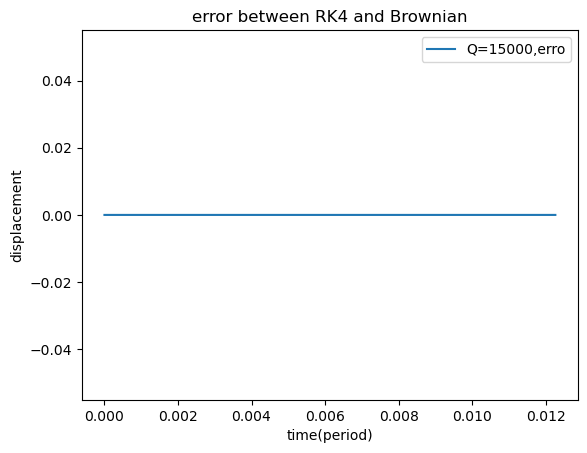

In [4]:
Q_l=[1,10,100,1000,15000]
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)

kb = 1.38*10**-23
T = 0 # setting temp to be 0k, so there is no thermal jitter
k = 2.7*10**-3
w0 = 2*np.pi*8169.7
std_shotN = 0

n = 100.3#how many cycle in each pulse
X0_0 = [1,0]# initial displacement and velocity for simulation
p0 = np.pi/2

dw_l_ana = np.zeros(int(n*2*np.pi/dtau))
dw_l_sim = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw

di = -1

for Q in Q_l:
    print("----------------------------------------------------------------------------------------------")
    print('Q=',Q)
    sig_analytical = fc.analytical_sol_ringdown(X0_0,Q,dw_l_ana,dtau,p0)
    sig_analytical[:,0]= sig_analytical[:,0]/w0
    sig_simulation_RK4 = fc.solve_RK4(X0_0, dtau, Q, np.zeros((len(dw_l_ana),4)),dw_l_sim)
    sig_simulation_brownian = fc.brownian_simulator(T, k, Q, dtau, X0_0, dw_l_sim, std_shotN, withShotNoise=False)

    plt.plot(sig_analytical[:di,0],sig_analytical[:di, 1], label=f"Q={Q},Analytical")
    plt.plot(sig_analytical[:di,0],sig_simulation_RK4[ :di,1], label=f"Q={Q},Rk4")
    # plt.plot(sig_analytical[:di,0],sig_simulation_brownian[ :di,1], label=f"Q={Q},Brownian")
    plt.title('ring-down trajectory solved by forward RK4 method and analytical solution')
    plt.ylabel('displacement')
    plt.xlabel('time(period)')
    plt.legend()
    plt.show()

    plt.plot(sig_analytical[:,0],sig_analytical[:,1] - sig_simulation_brownian[:,1], label=f"Q={Q},erro")
    plt.title('error of ring-down trajectory solved by forward RK4 method')
    plt.ylabel('displacement')
    plt.xlabel('time(period)')
    plt.legend()
    plt.show()

    plt.plot(sig_analytical[:,0],sig_simulation_RK4[:,1] - sig_simulation_brownian[:,1], label=f"Q={Q},erro")
    plt.title('error between RK4 and Brownian')
    plt.ylabel('displacement')
    plt.xlabel('time(period)')
    plt.legend()
    plt.show()

We showed that:

1. our simulated signal has the right form
2. the erro is relative small, the maximum value is still smaller than 5%; the erro mainly come from the higher estimation of Q
3. We have properly encapsulated our Brownian simulator, and the results obtained using it are completely consistent with those obtained by simulating directly using RK4.

For our target signal (ring-down signal), the best way to generate it is still using the analytical method

# simulating the noise


In [8]:
Q_l = [1, 10, 100, 1000, 15000]
dtau = 0.05 * 2 * np.pi  # Our sampling rate is about 200kHz, w0 is about 8k, so about 20 times larger
dw = np.array([])  # We need to set the effective radial frequency for each set, w_eff = 1+dw, and the real radial frequency w(t) = w0*w_eff = w0*(1+dw)

kb = 1.38 * 10**-23
T = 0  # Set temperature to 0K, so there is no thermal jitter
k = 2.7 * 10**-3
w0 = 2 * np.pi * 8169.7
std_shotN = 0.1*10**-9

n = 100.3  # Number of cycles in each pulse
X0_0 = [1, 0]  # Initial displacement and velocity for simulation
p0 = np.pi / 2

dw_l_ana = np.zeros(int(n * 2 * np.pi / dtau))  # w = 1+dw
dw_l_sim = np.zeros((int(n * 2 * np.pi / dtau),4))  # w = 1+dw

sig_analytical = fc.analytical_sol_ringdown(X0_0, Q, dw_l_ana, dtau, p0)  # While generating the analytical trajectory, we also generate the correct time series
sig_analytical[:, 0] = sig_analytical[:, 0] / w0
t = sig_analytical[:, 0]

In [9]:
r = 100
N = 128
noise_negon_l = []
T = 275

dw_negoff_l = []
for i in range(N):
    if i%100==0:
        print(i//100)
    theta = np.random.rand()*2*np.pi
    X0_0 = [np.sqrt(kb*T*2/k)*np.cos(theta)*(0.8+0.4*np.random.rand())/r,np.sqrt(kb*T*2/k)*np.sin(theta)*(0.5+np.random.rand())/r]
    noise_negon = fc.brownian_simulator(T, k, Q, dtau, X0_0, dw_l_sim, std_shotN, withShotNoise=False)

    noise_negon_l.append(noise_negon)
    dw_negoff_l.append(dw_l_sim)


theta = np.random.rand()*2*np.pi
X0_eq = [np.sqrt(kb*T*2/k)*np.cos(theta)*(0.5+np.random.rand()),np.sqrt(kb*T*2/k)*np.sin(theta)*(0.5+np.random.rand())]
noise_negoff = fc.brownian_simulator(T, k, Q, dtau, X0_eq, np.concat(np.array(dw_negoff_l),axis=0), std_shotN, withShotNoise=False)






0
1


# Display results of several single simulations

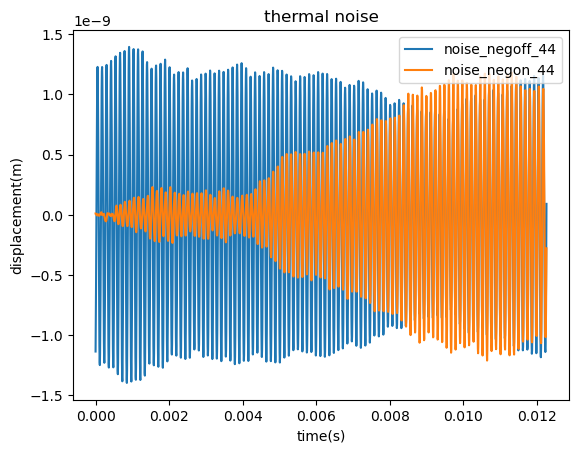

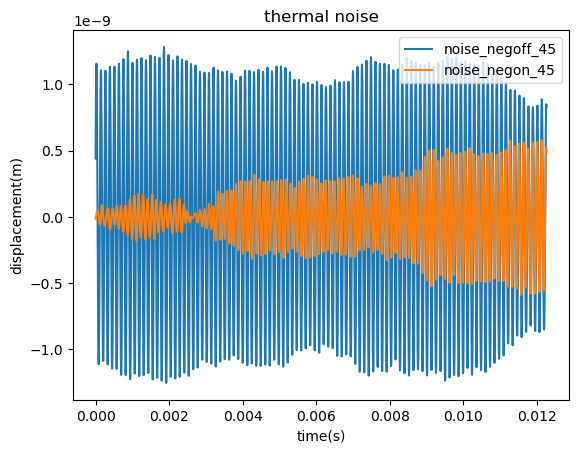

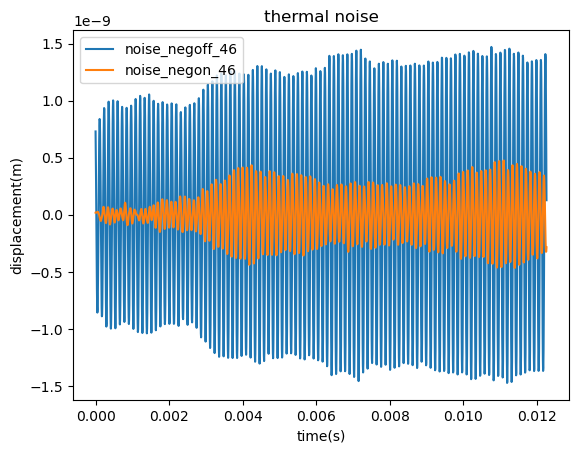

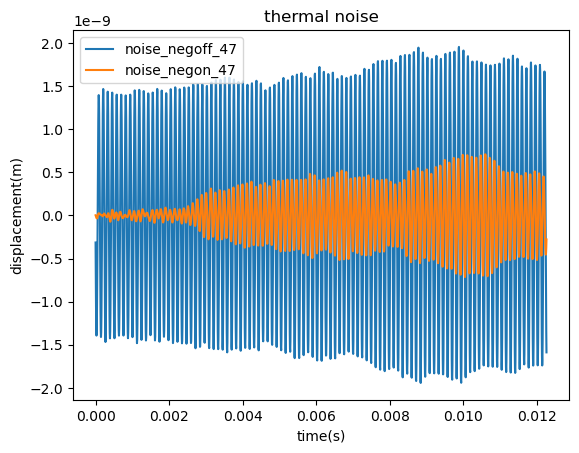

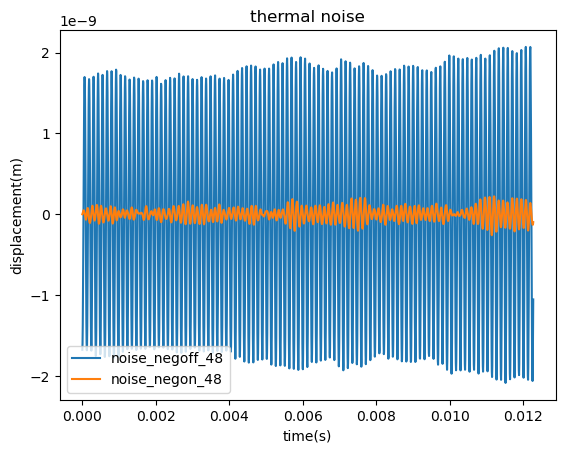

In [11]:
import matplotlib.pyplot as plt
for i in range(44,49):
    plt.plot(t,noise_negoff[i*len(t):(i+1)*len(t),0],label="noise_negoff_"+str(i))
    plt.plot(t,noise_negon_l[i][:,0],label="noise_negon_"+str(i))
    plt.xlabel("time(s)")
    plt.ylabel("displacement(m)")
    plt.title("thermal noise")
    plt.legend()
    plt.show()

# Averaging the squared noise values (essentially reflecting the variance dynamics)

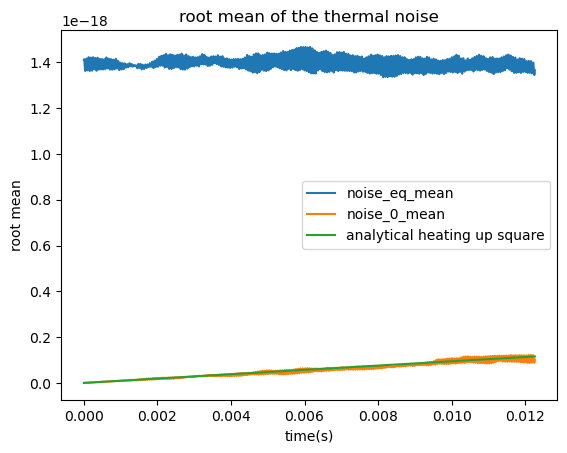

In [12]:
import matplotlib.pyplot as plt


noise_eq_x2_avg = 0
for i in range(N):
    noise_eq_x2_avg += noise_negoff[i*len(t):(i+1)*len(t),0]**2

noise_eq_x2_avg = noise_eq_x2_avg/N


plt.plot(t,np.array(noise_eq_x2_avg),label="noise_eq_mean")
plt.plot(t,np.mean(np.array(noise_negon_l)**2,axis=0)[:,0],label="noise_0_mean")
# y_negoff = kb * T / k *np.ones(len(t))
# plt.plot(t,y_negoff,label="analytical equilibrium square")
y_negon = kb * T*2 / k  * (1 - np.exp(-t *w0/ Q)) 
plt.plot(t,y_negon,label="analytical heating up square")
plt.legend()
plt.title("root mean of the thermal noise")
plt.ylabel("root mean")
plt.xlabel("time(s)")
plt.show()

# Saving

In [ ]:
params = {
    'Q': Q,
    'T': T,
    'k': k,
    'f0': w0 / (2 * np.pi),
    'r': r,
    't': sig_low[-1,0],
    'dw': dw_low[0]*w0
}

data = (sig_low,noise_negon_l,noise_negoff,params)



import os
import pickle
import h5py

import datetime
date_str = datetime.datetime.now().strftime("%Y-%m-%d")
name = date_str + " " + str(len(noise_0_low_l))+"x2 noise data MeasureTime="+str(sig_low[-1,0])+".h5"

os.makedirs('data', exist_ok=True)

with h5py.File('data/'+name, "w") as f:
    f["sig_low"] = sig_low
    f["noise_0_low_l"] = noise_0_low_l
    f["noise_0_high_l"] = noise_0_high_l
    f["noise_eq"] = noise_eq
    for keys in params.keys():
        f[str(keys)] = params[keys]
